# Late-time modelling

In [ ]:
from functools import partial
import numpy as np
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.fem import grid_average
from lucifex.viz import (
    plot_colormap, plot_line, save_figure, create_multifigure,
    plot_colormap_multifigure, plot_line_multifigure,
)
from lucifex.utils.array_utils import as_index
from lucifex.io import create_dir_path, find_dir_paths
from lucifex.utils.py_utils import FrozenDict
from lucifex.utils.array_utils import derivative, resample
from lucifex.sim import GridSimulationFromNPZ
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from crocodil.theory.system_a.late import LateTimeModel

# searching for all simulations in the batch
PARAMS_NUMERICAL = FrozenDict(
    c_stabilization=None,
    c_limits=True,
)
DIR_ROOT = create_dir_path(
    PARAMS_NUMERICAL, 
    dir_root='./',
    dir_prefix='data', 
    dir_params=PARAMS_NUMERICAL.keys(), 
)
DIR_FIGS = f'{DIR_ROOT}/figures'

T_STOP = 120.0
sim_dir_paths = find_dir_paths(
    DIR_ROOT, 
    include=f't_stop={T_STOP}_*',
    contains=('CHECKPOINT.h5', 'c.npz'),
)

# selecting a subset of simulations within the batch
PARAMS_SUBSET = SYSTEM_A_REFERENCE.replace(sr=0.2)

simulations = GridSimulationFromNPZ.dict_from_dir_paths(
    ('Ra', 'Da'), 
    sim_dir_paths,
    ('c', 's'),
    ('f', 'mD', 'mC', 'uRMS'),
    PARAMS_SUBSET,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)

# utilities for plotting
PARAM_REPR = lambda p: int(p) if isinstance(p, float) and float.is_integer(p) else p
save_figure = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix='early_similarity', 
    pickle=True,
    file_ext=('svg', 'png'),
)

In [ ]:
print('Before parameter selection')
for i in sim_dir_paths: print(i)
print('After parameter selection')
for i in simulations.values(): print(i.dir_path)

In [ ]:
sim = simulations[(1000.0, 100.0)]



In [ ]:
gamma = 1.0

legend_title = f'$\gamma={gamma}$\n$(\\alpha, \\beta)$'
legend_labels = ['DNS']
fDNS = fZeta0
f_lines = [(fDNS.time_series, [np.sum(i) for i in fDNS.value_series])]
mC_lines = [(mC.time_series, mC.value_series)]
mD_lines = [(mD.time_series, mD.value_series)]
cPlus_lines = [(cPlus.time_series, cPlus.value_series)]
cMinus_lines = [(cMinus.time_series, cMinus.value_series)]
sPlus_lines = [(sPlus.time_series, sPlus.value_series)]

t_ics_model = 7.0 # TODO deduce this programatically
t_ics_model_index = as_index(fDNS.time_series, t_ics_model)
t_model = fDNS.time_series[t_ics_model_index:]

ics_model = (
    cPlus.value_series[t_ics_model_index],
    cMinus.value_series[t_ics_model_index],
    sPlus.value_series[t_ics_model_index],
)

flux = lambda cp, cm, alpha, beta: (
    alpha * (cp - cm) + beta * (cp - cm) ** 2
)
alpha_opts = (0, 0.05)
beta_opts = (0.1, 0)

for alpha, beta in zip(alpha_opts, beta_opts):
    late_model = LateTimeModel(
        t_model,
        Lx * Ly,
        Da,
        epsilon,
        zeta0,
        sr,
        cr,
        gamma,
        partial(flux, alpha=alpha, beta=beta),
        constraint=False,
        ics=ics_model,
    )
    f_lines.append((late_model.t, -late_model.f))
    mC_lines.append((late_model.t, late_model.mC))
    mD_lines.append((late_model.t, late_model.mD))
    cPlus_lines.append((late_model.t, late_model.cPlus))
    cMinus_lines.append((late_model.t, late_model.cMinus))
    sPlus_lines.append((late_model.t, late_model.sPlus))
    legend_labels.append(f'({alpha}, {beta})')

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$t$', ylabel='$-F/(c^+ - c^-)^2$'>)

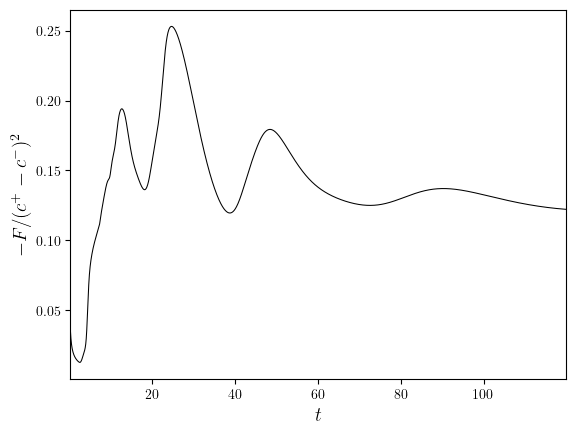

In [ ]:
# tFine = fZeta0.time_series
# cPlusFine = resample(cPlus.value_series, cPlus.time_series, tFine)
# cMinusFine = resample(cMinus.value_series, cMinus.time_series, tFine)
# # fZeta0Fine = resample(fZeta0.value_series, fZeta0.time_series, tFine)

# fRatio_expnt = 2
# fRatio = [
#     -np.sum(flx) / (cp - cm)**fRatio_expnt 
#     for flx, cp, cm in zip(fZeta0.value_series, cPlusFine, cMinusFine, strict=True)
# ]

# fRatio_slc = (10, None)
# fRatio_slc = slice(*fRatio_slc)
# plot_line(
#     (tFine[fRatio_slc], fRatio[fRatio_slc]),
#     y_label=f'$-F/(c^+ - c^-)^{fRatio_expnt}$',
#     x_label='$t$',
# )